<a href="https://colab.research.google.com/github/Bhuvanesh0301b/emotion-music-player/blob/main/notebooks/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

myDrive = '/content/drive/MyDrive'
for item in os.listdir(myDrive):
    print(item)


Colab Notebooks
Bhuvanesh.JPG
IMG_20221117_191635.jpg
Classroom
Assignment essay about cooking by  Abilash B.gdoc
Bhuvanesh.D.pdf
IMG_20221215_112430 (2).jpg
IMG_20221215_112527 (1).jpg
IMG_20221215_105655 (1).jpg
IMG_20221215_110343 (3).jpg
IMG_20221215_105721 (1).jpg
IMG_20221215_105712 (1).jpg
IMG_20221215_112602 (1).jpg
IMG_20221215_112527.jpg
IMG_20221215_112430 (1).jpg
IMG_20221215_112459 (3).jpg
IMG_20230117_101632 (1).jpg
IMG_20221215_110343 (2).jpg
IMG_20221215_112459 (2).jpg
IMG-20220620-WA0004.jpg
IMG-20220503-WA0011.jpg
IMG-20220511-WA0012.jpg
IMG-20220503-WA0013.jpg
IMG-20220503-WA0012.jpg
IMG-20220511-WA0011.jpg
Screenshot_20211130-184146_Chrome.jpg
Screenshot_20220603-180312_Chrome.jpg
IMG-20220620-WA0009.jpg
IMG-20220620-WA0008.jpg
Screenshot_20220806_151354.jpg
IMG-20220827-WA0004.jpg
IMG-20221001-WA0004.jpg
IMG-20221001-WA0003.jpg
IMG_20220930_181359.jpg
IMG_20221215_105622.jpg
IMG_20221215_105712.jpg
IMG_20221215_105721.jpg
IMG_20221215_105734.jpg
IMG_20221215_105730

In [ ]:
import zipfile
import os

zip_path     = '/content/drive/MyDrive/fer2013.zip'
extract_path = '/content/fer2013'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extraction complete!")

# Check folder structure
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        print(root)

Extraction complete!
/content/fer2013
/content/fer2013/test
/content/fer2013/test/angry
/content/fer2013/test/fear
/content/fer2013/test/surprise
/content/fer2013/test/sad
/content/fer2013/test/disgust
/content/fer2013/test/neutral
/content/fer2013/test/happy
/content/fer2013/train
/content/fer2013/train/angry
/content/fer2013/train/fear
/content/fer2013/train/surprise
/content/fer2013/train/sad
/content/fer2013/train/disgust
/content/fer2013/train/neutral
/content/fer2013/train/happy


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

# Check your extracted folder structure and set correct path
extract_path = '/content/fer2013'

# List contents to find train folder
for item in os.listdir(extract_path):
    print(item)

test
train


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                     Dropout, Flatten, Dense)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = '/content/fer2013/train'   # we'll confirm this after Cell 4

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Classes found:", train_gen.class_indices)

model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1), padding='same'),
    BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=3, factor=0.5),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/emotion_model.h5',
        save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Classes found: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,096,199 (19.44 MB)

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.6022 - loss: 1.0535 - val_accuracy: 0.6041 - val_loss: 1.0664 - learning_rate: 1.2500e-04
Epoch 26/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6046 - loss: 1.0552 - val_accuracy: 0.5989 - val_loss: 1.0736 - learning_rate: 1.2500e-04
Epoch 27/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6080 - loss: 1.0382 - val_accuracy: 0.5983 - val_loss: 1.0715 - learning_rate: 1.2500e-04
Epoch 28/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.6133 - loss: 1.0376 - val_accuracy: 0.5985 - val_loss: 1.0674 - learning_rate: 1.2500e-04
Epoch 29/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.6116 - loss: 1.0243 - val_accuracy: 0.6032 - val_loss: 1.0604 - learning_rate: 6.2500e-05
Epoch 30/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6096 - loss: 1.0247

359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.6122 - loss: 1.0268 - val_accuracy: 0.6044 - val_loss: 1.0720 - learning_rate: 6.2500e-05
Epoch 31/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 67ms/step - accuracy: 0.6129 - loss: 1.0278 - val_accuracy: 0.5997 - val_loss: 1.0536 - learning_rate: 6.2500e-05
Epoch 32/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6115 - loss: 1.0247

359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6115 - loss: 1.0286 - val_accuracy: 0.6067 - val_loss: 1.0556 - learning_rate: 6.2500e-05
Epoch 33/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.6118 - loss: 1.0236 - val_accuracy: 0.5957 - val_loss: 1.0644 - learning_rate: 6.2500e-05
Epoch 34/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6187 - loss: 1.0169 - val_accuracy: 0.5982 - val_loss: 1.0623 - learning_rate: 6.2500e-05
Epoch 35/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6143 - loss: 1.0218

359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.6179 - loss: 1.0132 - val_accuracy: 0.6116 - val_loss: 1.0528 - learning_rate: 3.1250e-05
Epoch 36/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6159 - loss: 1.0178

359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.6193 - loss: 1.0137 - val_accuracy: 0.6117 - val_loss: 1.0495 - learning_rate: 3.1250e-05
Epoch 37/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.6180 - loss: 1.0061 - val_accuracy: 0.6036 - val_loss: 1.0540 - learning_rate: 3.1250e-05
Epoch 38/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6165 - loss: 1.0143 - val_accuracy: 0.6098 - val_loss: 1.0519 - learning_rate: 3.1250e-05
Epoch 39/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6187 - loss: 1.0127 - val_accuracy: 0.6067 - val_loss: 1.0782 - learning_rate: 3.1250e-05
Epoch 40/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.6194 - loss: 1.0095 - val_accuracy: 0.6060 - val_loss: 1.0533 - learning_rate: 1.5625e-05
Epoch 41/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6218 - loss: 1.0090 - val_accuracy: 0.6067 - val_loss: 1.0580 - learning_rate: 1.5625e-05


In [ ]:
model.save('/content/drive/MyDrive/emotion_model.h5')
print("Model saved to Google Drive!")

Model saved to Google Drive!


In [14]:
import os

for item in os.listdir('/content/drive/MyDrive'):
    if 'fer' in item.lower() or 'archive' in item.lower():
        print(repr(item))

'fer2013.zip'


In [15]:
import zipfile
import os

zip_path     = '/content/drive/MyDrive/fer2013.zip'
extract_path = '/content/fer2013'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extraction complete!")

# Check folder structure
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        print(root)

Extraction complete!
/content/fer2013
/content/fer2013/test
/content/fer2013/test/angry
/content/fer2013/test/fear
/content/fer2013/test/surprise
/content/fer2013/test/sad
/content/fer2013/test/disgust
/content/fer2013/test/neutral
/content/fer2013/test/happy
/content/fer2013/train
/content/fer2013/train/angry
/content/fer2013/train/fear
/content/fer2013/train/surprise
/content/fer2013/train/sad
/content/fer2013/train/disgust
/content/fer2013/train/neutral
/content/fer2013/train/happy


In [16]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                     Dropout, Flatten, Dense)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = '/content/fer2013/train'

# Data generators
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Classes found:", train_gen.class_indices)
print("Training samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)

# Build CNN model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1), padding='same'),
    BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Classes found: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training samples: 22968
Validation samples: 5741


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,096,199 (19.44 MB)

 Trainable params: 5,094,279 (19.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.5,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/emotion_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks
)

print("\nTraining complete!")

Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2223 - loss: 2.5004
Epoch 1: val_accuracy improved from None to 0.28932, saving model to /content/drive/MyDrive/emotion_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.2586 - loss: 2.1713 - val_accuracy: 0.2893 - val_loss: 2.0409 - learning_rate: 0.0010
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3499 - loss: 1.7231
Epoch 2: val_accuracy improved from 0.28932 to 0.38199, saving model to /content/drive/MyDrive/emotion_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.3683 - loss: 1.6639 - val_accuracy: 0.3820 - val_loss: 1.5900 - learning_rate: 0.0010
Epoch 3/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4148 - loss: 1.5126
Epoch 3: val_accuracy improved from 0.38199 to 0.43512, saving model to /content/drive/MyDrive/emotion_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.4282 - loss: 1.4810 - val_accuracy: 0.4351 - val_loss: 1.4760 - learning_rate: 0.0010
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4535 - loss: 1.4175
Epoch 4: val_accuracy did not improve from 0.43512
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.4592 - loss: 1.4116 - val_accuracy: 0.4083 - val_loss: 1.5167 - learning_rate: 0.0010
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4863 - loss: 1.3437
Epoch 5: val_accuracy improved from 0.43512 to 0.47274, saving model to /content/drive/MyDrive/emotion_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.4829 - loss: 1.3504 - val_accuracy: 0.4727 - val_loss: 1.3657 - learning_rate: 0.0010
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4941 - loss: 1.3152
Epoch 6: val_accuracy did not improve from 0.47274
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.4963 - loss: 1.3106 - val_accuracy: 0.4489 - val_loss: 1.4250 - learning_rate: 0.0010
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5081 - loss: 1.2917
Epoch 7: val_accuracy did not improve from 0.47274
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.5124 - loss: 1.2872 - val_accuracy: 0.4567 - val_loss: 1.7436 - learning_rate: 0.0010
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5152 - loss: 1.2741
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: val_accuracy did not improve from 0.47274
359/3

...


Epoch 24: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.6073 - loss: 1.0420 - val_accuracy: 0.5983 - val_loss: 1.0762 - learning_rate: 2.5000e-04
Epoch 25/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6135 - loss: 1.0303
Epoch 25: val_accuracy did not improve from 0.59833
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6097 - loss: 1.0372 - val_accuracy: 0.5802 - val_loss: 1.1263 - learning_rate: 2.5000e-04
Epoch 26/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6147 - loss: 1.0232
Epoch 26: val_accuracy did not improve from 0.59833
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6112 - loss: 1.0281 - val_accuracy: 0.5849 - val_loss: 1.1030 - learning_rate: 2.5000e-04
Epoch 27/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6128 - loss: 1.0256
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 27: val_accuracy did not improv


Epoch 28: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.6200 - loss: 1.0068 - val_accuracy: 0.6009 - val_loss: 1.0542 - learning_rate: 1.2500e-04
Epoch 29/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6267 - loss: 0.9943
Epoch 29: val_accuracy improved from 0.60094 to 0.60321, saving model to /content/drive/MyDrive/emotion_model.h5



Epoch 29: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.6251 - loss: 1.0025 - val_accuracy: 0.6032 - val_loss: 1.0421 - learning_rate: 1.2500e-04
Epoch 30/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6229 - loss: 0.9959
Epoch 30: val_accuracy did not improve from 0.60321
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6244 - loss: 0.9983 - val_accuracy: 0.5982 - val_loss: 1.0611 - learning_rate: 1.2500e-04
Epoch 31/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6190 - loss: 1.0001
Epoch 31: val_accuracy did not improve from 0.60321
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6246 - loss: 0.9934 - val_accuracy: 0.6023 - val_loss: 1.0482 - learning_rate: 1.2500e-04
Epoch 32/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6311 - loss: 0.9903
Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 32: val_accuracy improved from 0


Epoch 32: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - accuracy: 0.6299 - loss: 0.9866 - val_accuracy: 0.6145 - val_loss: 1.0474 - learning_rate: 1.2500e-04
Epoch 33/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6341 - loss: 0.9760
Epoch 33: val_accuracy did not improve from 0.61453
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 68ms/step - accuracy: 0.6332 - loss: 0.9801 - val_accuracy: 0.6103 - val_loss: 1.0386 - learning_rate: 6.2500e-05
Epoch 34/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6394 - loss: 0.9682
Epoch 34: val_accuracy did not improve from 0.61453
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.6370 - loss: 0.9734 - val_accuracy: 0.6121 - val_loss: 1.0524 - learning_rate: 6.2500e-05
Epoch 35/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6352 - loss: 0.9670
Epoch 35: val_accuracy did not improve from 0.61453
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6298 -


Epoch 36: finished saving model to /content/drive/MyDrive/emotion_model.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.6301 - loss: 0.9778 - val_accuracy: 0.6180 - val_loss: 1.0385 - learning_rate: 6.2500e-05
Epoch 37/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6403 - loss: 0.9653
Epoch 37: val_accuracy did not improve from 0.61801
359/359 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.6390 - loss: 0.9721 - val_accuracy: 0.6029 - val_loss: 1.0568 - learning_rate: 6.2500e-05
Epoch 38/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6390 - loss: 0.9609
Epoch 38: val_accuracy did not improve from 0.61801
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6372 - loss: 0.9675 - val_accuracy: 0.6126 - val_loss: 1.0268 - learning_rate: 6.2500e-05
Epoch 39/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6361 - loss: 0.9628
Epoch 39: val_accuracy did not improve from 0.61801
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.6396 -

Model saved to Google Drive!


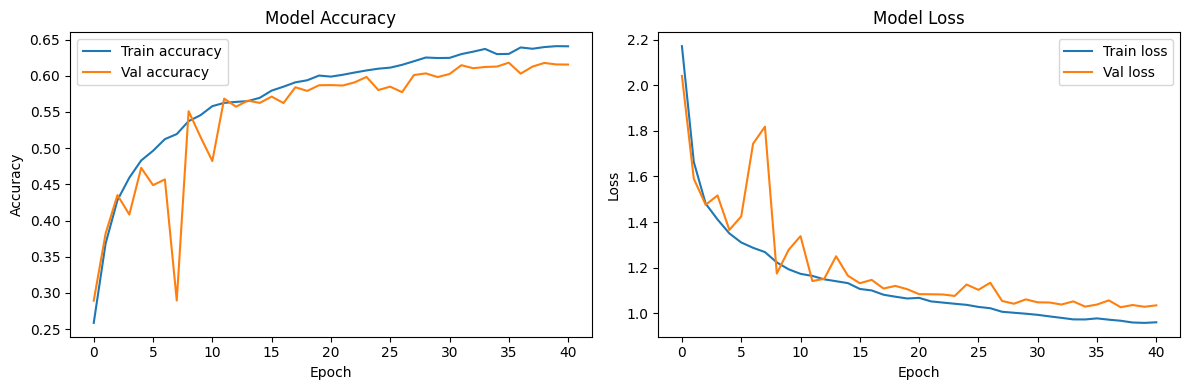

Plot saved to Google Drive!


In [19]:
import matplotlib.pyplot as plt

# Save model
model.save('/content/drive/MyDrive/emotion_model.h5')
print("Model saved to Google Drive!")

# Plot accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],   label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_plot.png')
plt.show()
print("Plot saved to Google Drive!")

In [20]:
import os

# Check if model file exists in Colab
if os.path.exists('/content/drive/MyDrive/emotion_model.h5'):
    print("Found in MyDrive!")
else:
    print("Not in MyDrive - saving now...")
    model.save('/content/drive/MyDrive/emotion_model.h5')
    print("Saved successfully!")

Found in MyDrive!


In [21]:
# Check if training data still exists
import os
print(os.path.exists('/content/fer2013/train'))

True


In [22]:
import os

drive_path = '/content/drive/MyDrive'
print("All files in your Google Drive:")
for item in os.listdir(drive_path):
    print(item)

All files in your Google Drive:
Colab Notebooks
Bhuvanesh.JPG
IMG_20221117_191635.jpg
Classroom
Assignment essay about cooking by  Abilash B.gdoc
Bhuvanesh.D.pdf
IMG_20221215_112430 (2).jpg
IMG_20221215_112527 (1).jpg
IMG_20221215_105655 (1).jpg
IMG_20221215_110343 (3).jpg
IMG_20221215_105721 (1).jpg
IMG_20221215_105712 (1).jpg
IMG_20221215_112602 (1).jpg
IMG_20221215_112527.jpg
IMG_20221215_112430 (1).jpg
IMG_20221215_112459 (3).jpg
IMG_20230117_101632 (1).jpg
IMG_20221215_110343 (2).jpg
IMG_20221215_112459 (2).jpg
IMG-20220620-WA0004.jpg
IMG-20220503-WA0011.jpg
IMG-20220511-WA0012.jpg
IMG-20220503-WA0013.jpg
IMG-20220503-WA0012.jpg
IMG-20220511-WA0011.jpg
Screenshot_20211130-184146_Chrome.jpg
Screenshot_20220603-180312_Chrome.jpg
IMG-20220620-WA0009.jpg
IMG-20220620-WA0008.jpg
Screenshot_20220806_151354.jpg
IMG-20220827-WA0004.jpg
IMG-20221001-WA0004.jpg
IMG-20221001-WA0003.jpg
IMG_20220930_181359.jpg
IMG_20221215_105622.jpg
IMG_20221215_105712.jpg
IMG_20221215_105721.jpg
IMG_2022121